In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib as mpl

# Set default plot properties (rcParams)
plt.rcParams['figure.figsize'] = [15, 8]  # Set the default figure size (width, height)
plt.rcParams['figure.dpi'] = 300  # Set the resolution (300 DPI for high-quality output)
plt.rcParams['lines.linewidth'] = 1     # Set default line width
plt.rcParams['lines.color'] = 'b'         # Set default line color (blue in this case)
plt.rcParams['axes.grid'] = True 
plt.rcParams['axes.grid.axis'] = 'y'
plt.rcParams['grid.alpha'] = 0.3    
plt.rcParams['axes.titlecolor'] = '#616161'
plt.rcParams['axes.labelcolor'] = '#616161'
plt.rcParams['xtick.color'] = '#616161'
plt.rcParams['ytick.color'] = '#616161'
plt.rcParams['text.color'] = '#616161'
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.markerscale'] = 1
plt.rcParams['legend.framealpha'] = 0.5
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.bottom'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#BCCF02", "#6C9C30", "#3E5C17", "#a7b805"]) 
# plt.rcParams["patch.facecolor"] = "#BCCF02"

plt.rcParams['figure.constrained_layout.use'] = True # alternativ zu tight_layout(). noch testen sonst deaktivieren

In [ ]:
import pandas as pd


spot_path = r'C:\Users\ckw-ThCa\OneDrive - CKW-Gruppe\Origination-General\Team\Caspar\Model_HEMS\hems_resopt\data\01_raw\spot_ch_25.xlsx'
HEADER_ROW_SPOT     = 0
df_spot = pd.read_excel(spot_path, header=HEADER_ROW_SPOT)
spot_column = 'Spot CH [Euro/MWh]'

df_spot['UTC'] = pd.to_datetime(df_spot['UTC'], utc=True)
df_spot.set_index('UTC', inplace=True)
spot_price_series = df_spot['Spot CH [Euro/MWh]']



galliker_25 = r'C:\Users\ckw-ThCa\OneDrive - CKW-Gruppe\Origination-General\Team\Caspar\Model_HEMS\hems_resopt\data\03_processed\Schachen\Front-of-meter\galliker_schachen_2025.csv'
galliker_26 = r'C:\Users\ckw-ThCa\OneDrive - CKW-Gruppe\Origination-General\Team\Caspar\Model_HEMS\hems_resopt\data\03_processed\Schachen\Front-of-meter\galliker_schachen_2026.csv'
df_galliker_25 = pd.read_csv(galliker_25)
df_galliker_26 = pd.read_csv(galliker_26)

# Explicitly parse the timestamp column as UTC-aware datetimes
df_galliker_25['timestamp'] = pd.to_datetime(df_galliker_25['timestamp'], utc=True)
df_galliker_26['timestamp'] = pd.to_datetime(df_galliker_26['timestamp'], utc=True)

# Convert from UTC to Europe/Zurich local time
df_galliker_25['timestamp'] = df_galliker_25['timestamp'].dt.tz_convert('Europe/Zurich')
df_galliker_26['timestamp'] = df_galliker_26['timestamp'].dt.tz_convert('Europe/Zurich')

df_galliker_25.set_index(df_galliker_25['timestamp'], inplace=True)
df_galliker_26.set_index(df_galliker_26['timestamp'], inplace=True)
df_galliker_25.drop(columns='timestamp', inplace=True)
df_galliker_26.drop(columns='timestamp', inplace=True)
df_galliker = pd.concat([df_galliker_25, df_galliker_26], axis=0).sort_index()
df_galliker[spot_column] = spot_price_series
df_galliker.head(5)

df_results = df_galliker

In [ ]:
# when making prices we need to differentiate between import and export. With imports we have to pay grid fees, when exporting we don't pay them and directly receive spot
arbeitspreis_netz_bezug = 42.4    # CHF/MWh
arbeitspreis_netz_einspeisung = 0

# monthly peak: grid_peak_shave__var_peak_power (incl. bess) -> min()

# bess bess_san_antonino__var_power_discharge, bess_san_antonino__var_power_charge, bess_san_antonino__var_power
# if bess_san_antonino__var_power is negative we charge (so all power flows which are negative take energy from the grid and if flow is positive we give energy)
# bess soc bess_san_antonino__var_soc_slot_start (tracking)

# PV spill = curtailement: PV_San_Antonino__var_spill
# PV_San_Antonino__var_power -> always positive = always power flow towards the grid

# Building -> lost load = curtailement: San_Antonino__var_lost_load
# San_Antonino__var_power -> load profile building

# check if bess power is integrated in San_Antonino__var_power -> btm construct built correctly
# I think bess is only visible in grid and spot powers, because we are looking at the power of the indivudual components and only in grid it is aggregated
# evt total is grid_peak_shave__var_power_export, grid_peak_shave__var_power_import

# Prices: if bess is correctly btm we have total costs as spot_ch__var_power * 0.25 (get energy) * price (from df_spot prices)
# check if spot_ch__var_power (incl. the sign) should be equal to (grid_peak_shave__var_power_export, -grid_peak_shave__var_power_import)
# when spot_ch__var_power negative we pay (import energy) and if positive we receive

# dayly, weekly,monthly total costs = spot_ch__var_power * spot_prices sum
# look at bess alone  bess_san_antonino__var_power * spot_prices (when negative we are charging)
# look at system without bess (PV_San_Antonino__var_power + San_Antonino__var_power) * spot_prices # peaks without bess = (PV_San_Antonino__var_power + San_Antonino__var_power).min(month)
# look at system with bess spot_ch__var_power * spot_prices

# indivudal graph
# visualize the peak loads with and without bess per month as a graph
# also calculate the peak costs with and without bess 



# individual graph 
# visualize the total load of the simulation with bess spot_ch__var_power and without bess PV_San_Antonino__var_power + San_Antonino__var_power
# in the same plot so that we can compare it

# individual graph
# visualize the total costs with and without bess per month and over the entire year (incl. peak costs of the month per case (with bess and without))

# individual graph
# make it modular so that one can add different lines from the simulation df_ (start with soc_slot_start, spot_prices)


# columns
# PV_San_Antonino__var_power + San_Antonino__var_power, grid_peak_shave__var_power_export, -grid_peak_shave__var_power_import, spot_ch__var_power
# bess_san_antonino__var_power_charge, bess_san_antonino__var_power

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

DT_HOURS = 0.25  # 15-min slot length in hours


def energy_cost(power_mw: pd.Series, spot_price_eur_mwh: pd.Series,
                 fee_import: float, fee_export: float) -> pd.Series:
    """Cost per timestep (CHF), given power in MW (negative = import/pay, positive = export/receive).

    Import price = spot + fee_import ; Export price = spot + fee_export (fee_export usually 0).
    We multiplied by -1 to make positive values being costs
    """
    price = spot_price_eur_mwh.where(power_mw >= 0, spot_price_eur_mwh + fee_import)
    price = price.where(power_mw < 0, spot_price_eur_mwh + fee_export)
    return power_mw * DT_HOURS * price * -1  # -1: negative power (import) -> positive cost


def monthly_peak(power_mw: pd.Series) -> pd.Series:
    """Monthly peak import (MW, positive value) — import is negative power, so peak = -min()."""
    return power_mw.groupby(power_mw.index.to_period('M')).min().mul(-1)


def peak_cost(peak_mw: pd.Series, price_per_mw: float) -> pd.Series:
    """Peak demand charge per month (CHF) = peak (MW) * price (CHF/MW)."""
    return peak_mw * price_per_mw


def plot_timeseries_columns(df: pd.DataFrame, columns: list[str], title: str,
                             ylabel: str = "Value", figsize=(12, 5)):
    """Modular line plot — plot any set of df columns over time."""
    fig, ax = plt.subplots(figsize=figsize, dpi=130)
    for col in columns:
        ax.plot(df.index, df[col], label=col, linewidth=1.5)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.legend(loc="best")
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()
    return fig


In [ ]:
kosten_lastspitze = 0      # 7190 CHF/MW   
arbeitspreis_netz_bezug = 0    # 42.4 CHF/MWh 
arbeitspreis_netz_einspeisung = 0

Anschlussleistung_SanAntonino = 1.6  # MW
cos_phi = 0.86
Anschlussleistung_Schachen = 0.935 * cos_phi  # MW

# ── Core power series ───────────────────────────────────────────────────────
power_with_bess    = df_results['spot_ch__var_power']
power_without_bess = df_results['Schachen__var_power'] + df_results['PV_San_Antonino__var_power']

spot_prices = spot_price_series  # your aligned EUR/MWh series, same index

# ── Energy costs ─────────────────────────────────────────────────────────────
cost_with_bess    = energy_cost(power_with_bess, spot_prices, arbeitspreis_netz_bezug, arbeitspreis_netz_einspeisung)
cost_without_bess = energy_cost(power_without_bess, spot_prices, arbeitspreis_netz_bezug, arbeitspreis_netz_einspeisung)

monthly_energy_cost = pd.DataFrame({
    'with_bess': cost_with_bess.groupby(cost_with_bess.index.to_period('M')).sum(),
    'without_bess': cost_without_bess.groupby(cost_without_bess.index.to_period('M')).sum(),
})

# ── Peaks & peak costs ────────────────────────────────────────────────────────
peaks = pd.DataFrame({
    'with_bess': monthly_peak(power_with_bess),
    'without_bess': monthly_peak(power_without_bess),
})
peak_costs = peaks.apply(lambda col: peak_cost(col, kosten_lastspitze))

monthly_total_cost = monthly_energy_cost + peak_costs
print("Annual total cost — with BESS:", monthly_total_cost['with_bess'].sum().round(0), "CHF")
print("Annual total cost — without BESS:", monthly_total_cost['without_bess'].sum().round(0), "CHF")

Annual total cost — with BESS: 55163.0 CHF
Annual total cost — without BESS: 304096.0 CHF


C:\Users\ckw-ThCa\AppData\Local\Temp\ipykernel_1172\3946367912.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  'with_bess': cost_with_bess.groupby(cost_with_bess.index.to_period('M')).sum(),
C:\Users\ckw-ThCa\AppData\Local\Temp\ipykernel_1172\3946367912.py:21: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  'without_bess': cost_without_bess.groupby(cost_without_bess.index.to_period('M')).sum(),


C:\Users\ckw-ThCa\AppData\Local\Temp\ipykernel_1172\3326454343.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


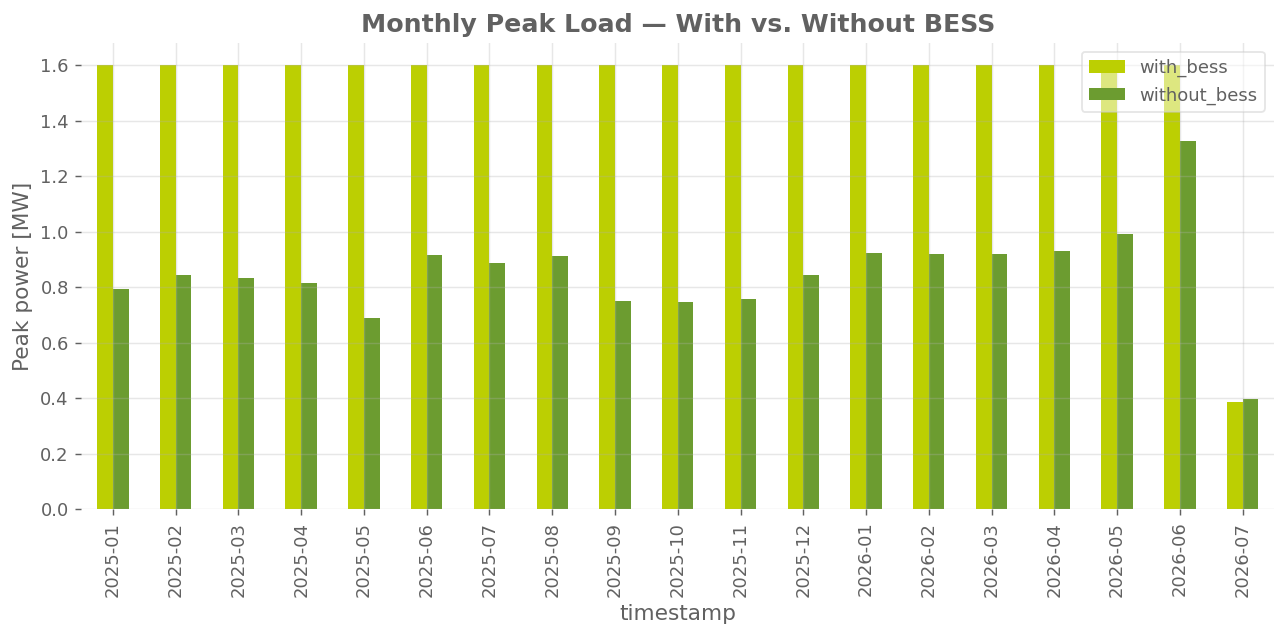

C:\Users\ckw-ThCa\AppData\Local\Temp\ipykernel_1172\1054879235.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


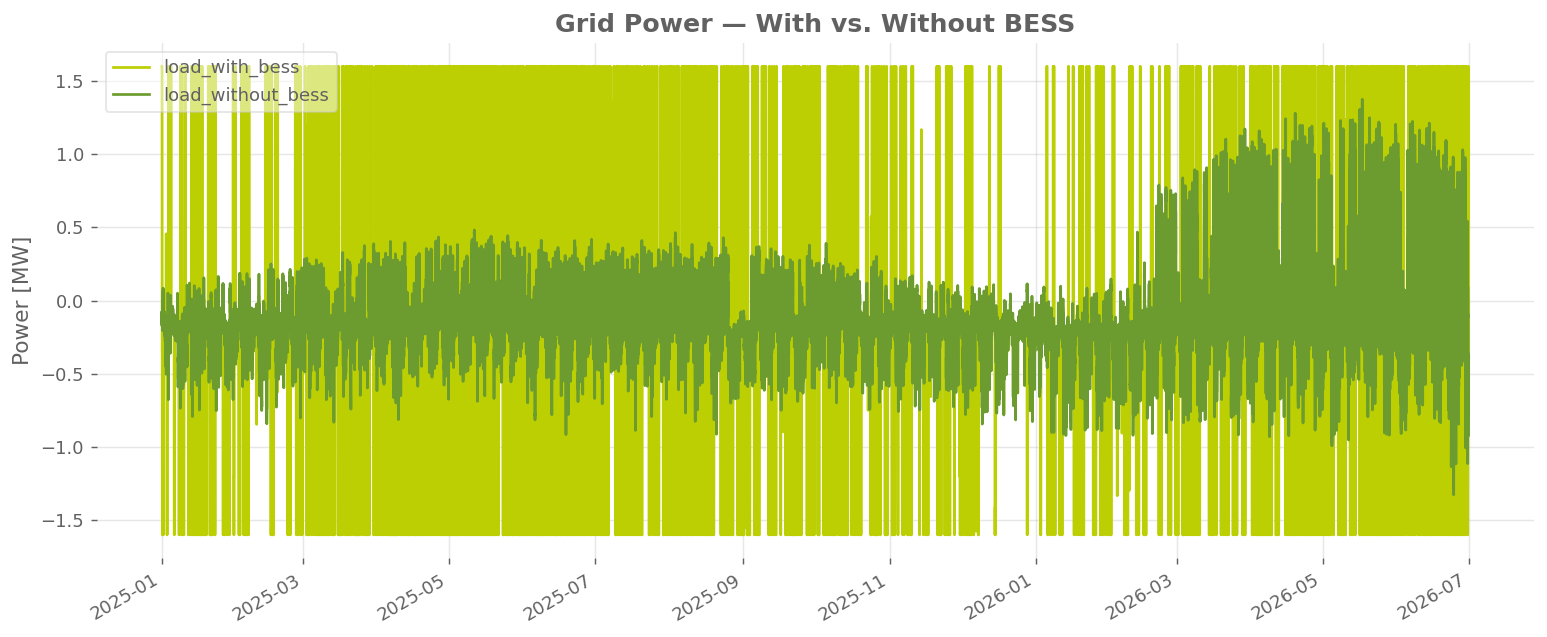

C:\Users\ckw-ThCa\AppData\Local\Temp\ipykernel_1172\3326454343.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


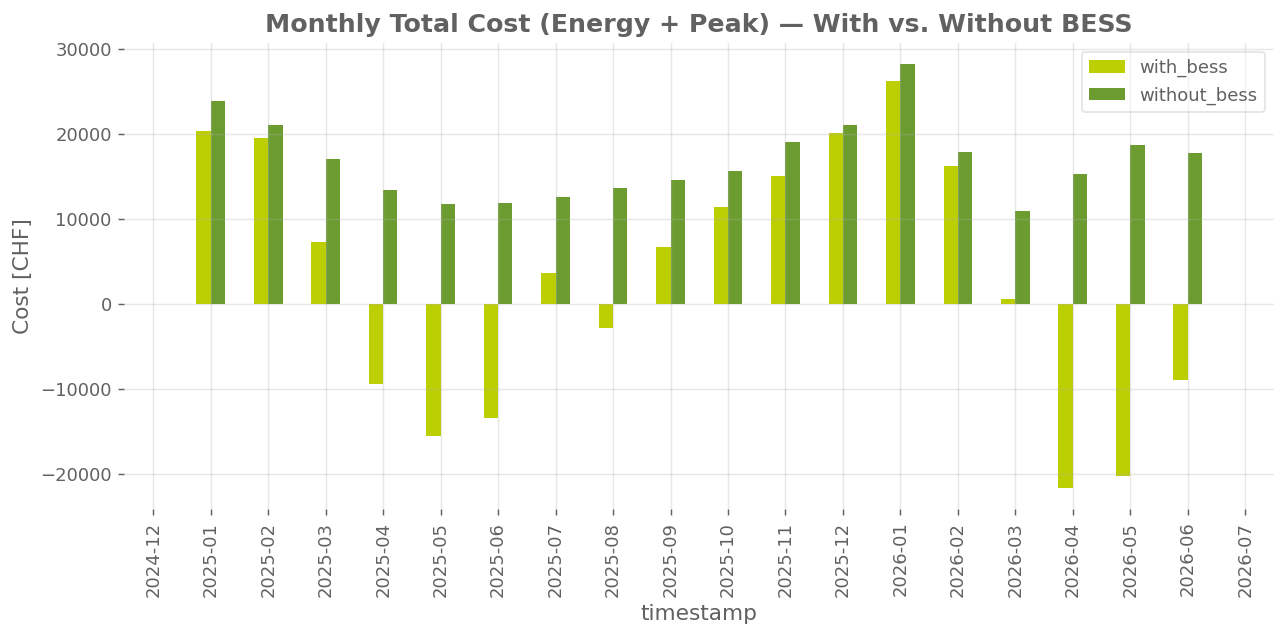

           with_bess  without_bess
timestamp                         
2024-12          NaN           NaN
2025-01      20385.0       23861.0
2025-02      19566.0       21039.0
2025-03       7270.0       17074.0
2025-04      -9440.0       13427.0
2025-05     -15553.0       11786.0
2025-06     -13419.0       11854.0
2025-07       3627.0       12534.0
2025-08      -2851.0       13618.0
2025-09       6722.0       14519.0
2025-10      11446.0       15641.0
2025-11      15100.0       18986.0
2025-12      20060.0       21019.0
2026-01      26225.0       28209.0
2026-02      16265.0       17832.0
2026-03        588.0       10934.0
2026-04     -21628.0       15335.0
2026-05     -20259.0       18726.0
2026-06      -8941.0       17700.0
2026-07          0.0           0.0


In [ ]:
# ── Graph 1: monthly peak loads, with vs. without BESS ───────────────────────
peaks_idx = peaks.copy()
peaks_idx.index = peaks_idx.index.astype(str)   # e.g. '2025-01' instead of a datetime/period

fig1, ax1 = plt.subplots(figsize=(10, 5), dpi=130)
peaks_idx.plot.bar(ax=ax1)
ax1.set_title("Monthly Peak Load — With vs. Without BESS", fontweight="bold")
ax1.set_ylabel("Peak power [MW]")
ax1.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# ── Graph 2: total load timeseries, with vs. without BESS ────────────────────
df_load_compare = pd.DataFrame({
    'load_with_bess': power_with_bess,
    'load_without_bess': power_without_bess,
})
plot_timeseries_columns(df_load_compare, df_load_compare.columns.tolist(),
                         title="Grid Power — With vs. Without BESS", ylabel="Power [MW]")
plt.show()

# ── Graph 3: total cost comparison — monthly & annual, incl. peak cost ──────
monthly_total_cost_idx = monthly_total_cost.copy()
monthly_total_cost_idx.index = monthly_total_cost_idx.index.astype(str)

fig3, ax3 = plt.subplots(figsize=(10, 5), dpi=130)
monthly_total_cost_idx.plot.bar(ax=ax3)
ax3.set_title("Monthly Total Cost (Energy + Peak) — With vs. Without BESS", fontweight="bold")
ax3.set_ylabel("Cost [CHF]")
ax3.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(monthly_total_cost.round(0))


In [ ]:
# monthly_total_cost.to_csv(r'C:\Users\ckw-ThCa\OneDrive - CKW-Gruppe\Origination-General\Team\Caspar\Model_HEMS\hems_resopt\data\03_processed\Galliker-front-of-meter\monthly_total_costs.csv')

C:\Users\ckw-ThCa\AppData\Local\Temp\ipykernel_1172\1054879235.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


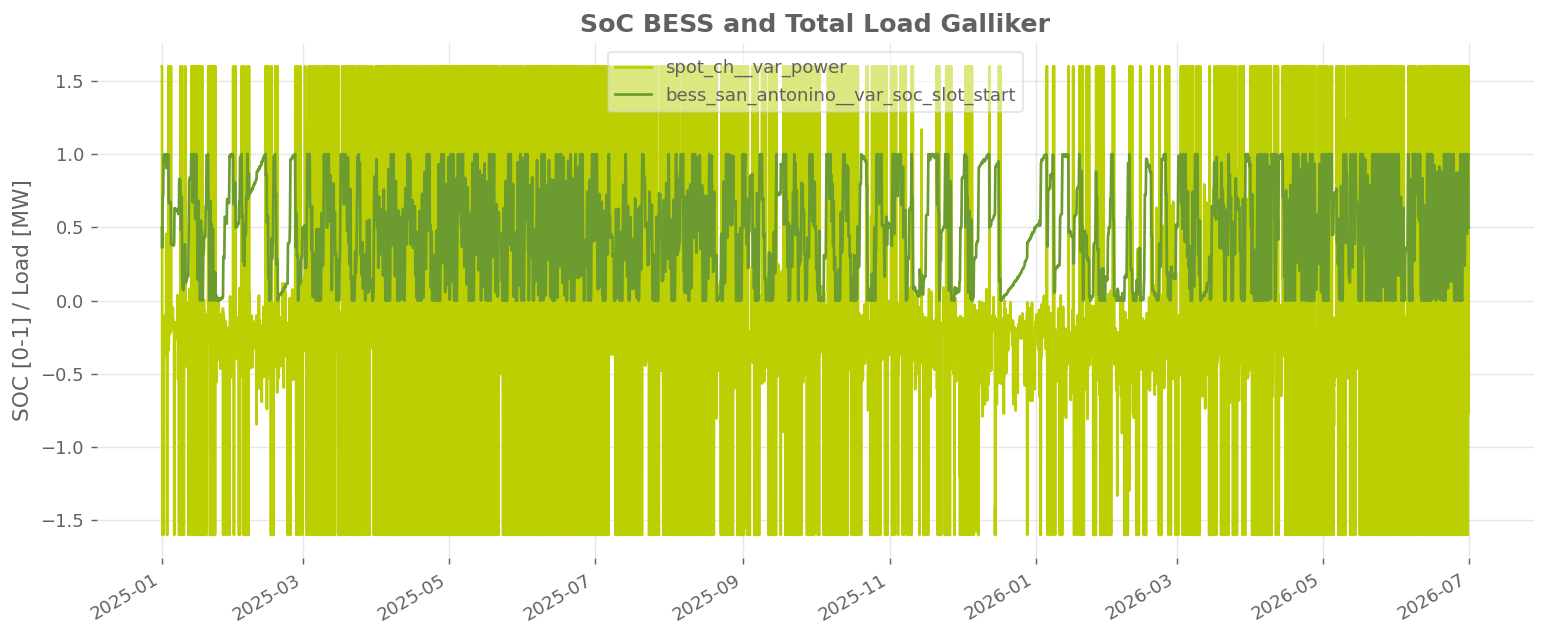

In [ ]:
# columns
# PV_San_Antonino__var_power + San_Antonino__var_power, grid_peak_shave__var_power_export, -grid_peak_shave__var_power_import, spot_ch__var_power
# bess_san_antonino__var_power_charge, bess_san_antonino__var_power, bess_san_antonino__var_soc_slot_start, Spot CH [Euro/MWh]

plot_timeseries_columns(
    df_results,
    columns=['spot_ch__var_power', 'bess_san_antonino__var_soc_slot_start'],
    title="SoC BESS and Total Load Galliker",
    ylabel="SOC [0-1] / Load [MW]",
)
plt.show()
